In [1]:
# Cell 1 — Install & imports
!pip install kaggle --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

print("All imports done ✓")

All imports done ✓


In [8]:
import zipfile
import os

# Unzip the file
with zipfile.ZipFile('booksgenre.zip', 'r') as z:
    z.extractall('.')
    print("Files extracted:", z.namelist())

Files extracted: ['Goodreads_books_with_genres.csv']


In [9]:
# Cell 2 — Load data
df = pd.read_csv('Goodreads_books_with_genres.csv')  # adjust filename if different
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nNull values:\n", df.isnull().sum())
df.head()

Shape: (11127, 13)

Columns: ['Book Id', 'Title', 'Author', 'average_rating', 'isbn', 'isbn13', 'language_code', 'num_pages', 'ratings_count', 'text_reviews_count', 'publication_date', 'publisher', 'genres']

Null values:
 Book Id                0
Title                  0
Author                 0
average_rating         0
isbn                   0
isbn13                 0
language_code          0
num_pages              0
ratings_count          0
text_reviews_count     0
publication_date       0
publisher              0
genres                97
dtype: int64


,Book Id,Title,Author,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,genres
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil..."
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil..."
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil..."
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil..."
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Adve..."


In [10]:
# Check actual column names first
print(df.columns.tolist())
print("\nShape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

['Book Id', 'Title', 'Author', 'average_rating', 'isbn', 'isbn13', 'language_code', 'num_pages', 'ratings_count', 'text_reviews_count', 'publication_date', 'publisher', 'genres']

Shape: (11127, 13)

First 3 rows:


,Book Id,Title,Author,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,genres
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil..."
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil..."
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil..."


In [11]:
# Step 3 — Preprocessing

# 1. Extract primary genre (first one before semicolon)
df['genre'] = df['genres'].apply(
    lambda x: str(x).split(';')[0].strip() if pd.notnull(x) else np.nan)

# 2. Check what genres we have
print("Top 15 genres:")
print(df['genre'].value_counts().head(15))

Top 15 genres:
genre
Fiction                          1862
Classics                          958
Fantasy                           802
Nonfiction                        801
Mystery                           554
History                           471
Philosophy                        374
Science Fiction                   347
Historical,Historical Fiction     312
Sequential Art,Manga              274
Horror                            260
Romance                           238
Biography                         205
Poetry                            200
Childrens                         192
Name: count, dtype: int64


In [12]:
# 3. Keep top 6 clean genres only
top_genres = ['Fiction', 'Classics', 'Fantasy', 'Nonfiction', 'Mystery', 'Science Fiction']
df = df[df['genre'].isin(top_genres)].copy()
print("Filtered shape:", df.shape)
print("\nGenre distribution:")
print(df['genre'].value_counts())

# 4. Clean numeric columns
df['num_pages'] = pd.to_numeric(df['num_pages'], errors='coerce')
df['average_rating'] = pd.to_numeric(df['average_rating'], errors='coerce')
df['ratings_count'] = pd.to_numeric(df['ratings_count'], errors='coerce')
df['text_reviews_count'] = pd.to_numeric(df['text_reviews_count'], errors='coerce')

# 5. Fill missing values
df['num_pages'] = df['num_pages'].fillna(df['num_pages'].median())
df['average_rating'] = df['average_rating'].fillna(df['average_rating'].mean())
df['ratings_count'] = df['ratings_count'].fillna(0)
df['text_reviews_count'] = df['text_reviews_count'].fillna(0)

# 6. Remove impossible values
df = df[df['num_pages'] > 0]

# 7. Log transform skewed columns
df['log_ratings_count'] = np.log1p(df['ratings_count'])
df['log_reviews_count'] = np.log1p(df['text_reviews_count'])

# 8. Extract publish year
df['publish_year'] = pd.to_datetime(
    df['publication_date'], errors='coerce').dt.year
df['publish_year'] = df['publish_year'].fillna(df['publish_year'].median())

# 9. Encode language
from sklearn.preprocessing import LabelEncoder
le_lang = LabelEncoder()
df['language_code'] = df['language_code'].fillna('Unknown')
df['language_encoded'] = le_lang.fit_transform(df['language_code'])

print("\nFinal cleaned shape:", df.shape)
print("\nNull values remaining:")
print(df[['average_rating','num_pages','log_ratings_count',
          'log_reviews_count','publish_year','language_encoded']].isnull().sum())

Filtered shape: (5324, 14)

Genre distribution:
genre
Fiction            1862
Classics            958
Fantasy             802
Nonfiction          801
Mystery             554
Science Fiction     347
Name: count, dtype: int64

Final cleaned shape: (5283, 18)

Null values remaining:
average_rating       0
num_pages            0
log_ratings_count    0
log_reviews_count    0
publish_year         0
language_encoded     0
dtype: int64


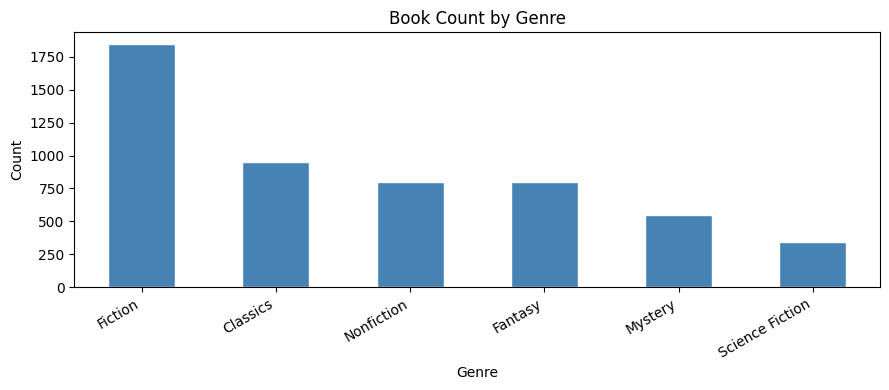

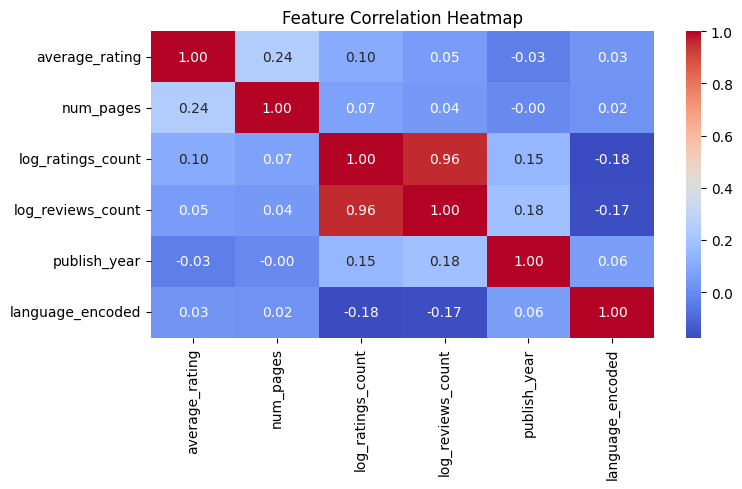

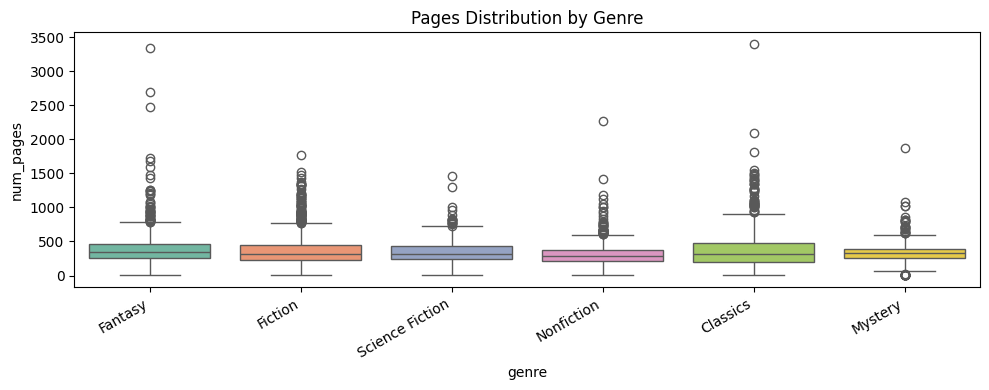

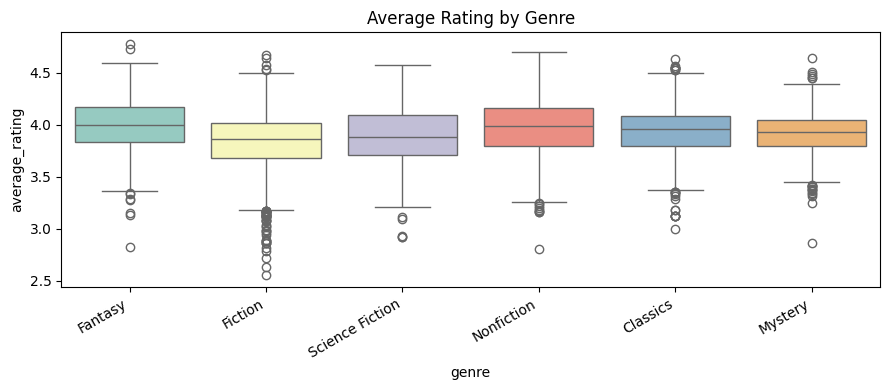

All EDA plots saved ✓


In [13]:
# Step 3 — EDA Visualizations

# 1. Genre distribution bar chart
plt.figure(figsize=(9,4))
df['genre'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title("Book Count by Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("genre_dist.png", dpi=150)
plt.show()

# 2. Correlation heatmap
feature_cols = ['average_rating','num_pages','log_ratings_count',
                'log_reviews_count','publish_year','language_encoded']
plt.figure(figsize=(8,5))
sns.heatmap(df[feature_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150)
plt.show()

# 3. Pages distribution by genre
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='genre', y='num_pages', palette='Set2')
plt.title("Pages Distribution by Genre")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("pages_by_genre.png", dpi=150)
plt.show()

# 4. Average rating by genre
plt.figure(figsize=(9,4))
sns.boxplot(data=df, x='genre', y='average_rating', palette='Set3')
plt.title("Average Rating by Genre")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("rating_by_genre.png", dpi=150)
plt.show()

print("All EDA plots saved ✓")

In [14]:
# Step 4 — Prepare Features + Train/Test Split

feature_cols = ['average_rating', 'num_pages', 'log_ratings_count',
                'log_reviews_count', 'publish_year', 'language_encoded']

X = df[feature_cols]
y = df['genre']

# Encode target labels
le_genre = LabelEncoder()
y_encoded = le_genre.fit_transform(y)

print("Classes:", le_genre.classes_)
print("Feature shape:", X.shape)

# Stratified split — ensures each genre proportionally in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"\nTrain size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

# Scale features for models that need it
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("\nTrain/Test split done ✓")
print("Scaling done ✓")

Classes: ['Classics' 'Fantasy' 'Fiction' 'Mystery' 'Nonfiction' 'Science Fiction']
Feature shape: (5283, 6)

Train size: (4226, 6)
Test size:  (1057, 6)

Train/Test split done ✓
Scaling done ✓


Logistic Regression                 | Accuracy: 39.17% | Time: 0.24s
KNN (k=5)                           | Accuracy: 36.52% | Time: 0.02s
SVM (RBF)                           | Accuracy: 42.29% | Time: 6.9s
Decision Tree                       | Accuracy: 33.02% | Time: 0.07s
Naive Bayes                         | Accuracy: 25.45% | Time: 0.02s

Classification Report — SVM:
                 precision    recall  f1-score   support

       Classics       0.37      0.30      0.33       191
        Fantasy       0.49      0.33      0.39       159
        Fiction       0.43      0.82      0.57       369
        Mystery       0.41      0.06      0.11       109
     Nonfiction       0.33      0.16      0.22       160
Science Fiction       0.43      0.04      0.08        69

       accuracy                           0.42      1057
      macro avg       0.41      0.29      0.28      1057
   weighted avg       0.41      0.42      0.37      1057



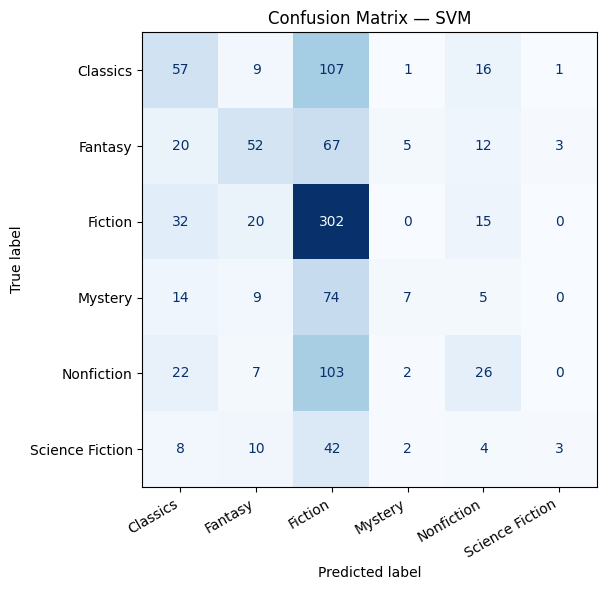


Base classifiers done ✓


In [15]:
# Step 5 — Classification Models

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

results = []

def evaluate_clf(name, model, Xtr, Xte, ytr, yte):
    start = time.time()
    model.fit(Xtr, ytr)
    elapsed = round(time.time() - start, 2)
    pred = model.predict(Xte)
    acc = round(accuracy_score(yte, pred) * 100, 2)
    print(f"{name:35s} | Accuracy: {acc}% | Time: {elapsed}s")
    return {"Model": name, "Accuracy(%)": acc, "Train Time(s)": elapsed}, pred

r1, p1 = evaluate_clf("Logistic Regression",
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_s, X_test_s, y_train, y_test)

r2, p2 = evaluate_clf("KNN (k=5)",
    KNeighborsClassifier(n_neighbors=5),
    X_train_s, X_test_s, y_train, y_test)

r3, p3 = evaluate_clf("SVM (RBF)",
    SVC(kernel='rbf', C=10, random_state=42),
    X_train_s, X_test_s, y_train, y_test)

r4, p4 = evaluate_clf("Decision Tree",
    DecisionTreeClassifier(max_depth=10, random_state=42),
    X_train, X_test, y_train, y_test)

r5, p5 = evaluate_clf("Naive Bayes",
    GaussianNB(),
    X_train, X_test, y_train, y_test)

results.extend([r1, r2, r3, r4, r5])

# Confusion matrix for best base model (SVM)
svm = SVC(kernel='rbf', C=10, random_state=42)
svm.fit(X_train_s, y_train)
svm_pred = svm.predict(X_test_s)

print("\nClassification Report — SVM:")
print(classification_report(y_test, svm_pred, target_names=le_genre.classes_))

cm = confusion_matrix(y_test, svm_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_genre.classes_)
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — SVM")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("confusion_matrix_svm.png", dpi=150)
plt.show()

print("\nBase classifiers done ✓")

Random Forest                       | Accuracy: 42.1% | Time: 3.89s
Gradient Boosting                   | Accuracy: 39.17% | Time: 14.39s
XGBoost                             | Accuracy: 40.3% | Time: 2.54s
AdaBoost                            | Accuracy: 36.42% | Time: 0.25s
Bagging                             | Accuracy: 38.69% | Time: 0.3s

Classification Report — XGBoost:
                 precision    recall  f1-score   support

       Classics       0.41      0.34      0.37       191
        Fantasy       0.47      0.33      0.39       159
        Fiction       0.46      0.67      0.54       369
        Mystery       0.23      0.17      0.19       109
     Nonfiction       0.29      0.26      0.27       160
Science Fiction       0.14      0.06      0.08        69

       accuracy                           0.40      1057
      macro avg       0.33      0.30      0.31      1057
   weighted avg       0.38      0.40      0.38      1057



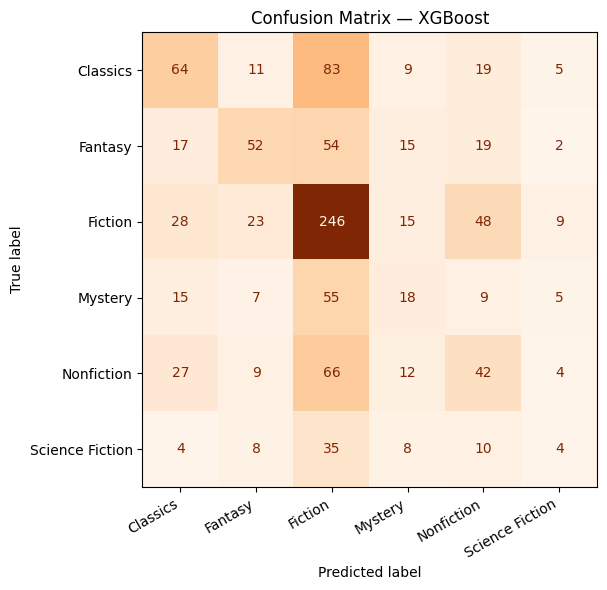


Ensemble methods done ✓


In [16]:
# Step 6 — Ensemble Methods

from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier,
                               AdaBoostClassifier,
                               BaggingClassifier)
from xgboost import XGBClassifier

r6, p6 = evaluate_clf("Random Forest",
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train, X_test, y_train, y_test)

r7, p7 = evaluate_clf("Gradient Boosting",
    GradientBoostingClassifier(random_state=42),
    X_train, X_test, y_train, y_test)

r8, p8 = evaluate_clf("XGBoost",
    XGBClassifier(random_state=42, verbosity=0, eval_metric='mlogloss'),
    X_train, X_test, y_train, y_test)

r9, p9 = evaluate_clf("AdaBoost",
    AdaBoostClassifier(random_state=42),
    X_train, X_test, y_train, y_test)

r10, p10 = evaluate_clf("Bagging",
    BaggingClassifier(random_state=42),
    X_train, X_test, y_train, y_test)

results.extend([r6, r7, r8, r9, r10])

# Confusion matrix for best ensemble (XGBoost)
xgb = XGBClassifier(random_state=42, verbosity=0, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("\nClassification Report — XGBoost:")
print(classification_report(y_test, xgb_pred, target_names=le_genre.classes_))

cm2 = confusion_matrix(y_test, xgb_pred)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=le_genre.classes_)
fig, ax = plt.subplots(figsize=(8,6))
disp2.plot(ax=ax, cmap='Oranges', colorbar=False)
plt.title("Confusion Matrix — XGBoost")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("confusion_matrix_xgb.png", dpi=150)
plt.show()

print("\nEnsemble methods done ✓")

Full Model Comparison:
              Model  Accuracy(%)  Train Time(s)
          SVM (RBF)        42.29           6.90
      Random Forest        42.10           3.89
            XGBoost        40.30           2.54
Logistic Regression        39.17           0.24
  Gradient Boosting        39.17          14.39
            Bagging        38.69           0.30
          KNN (k=5)        36.52           0.02
           AdaBoost        36.42           0.25
      Decision Tree        33.02           0.07
        Naive Bayes        25.45           0.02


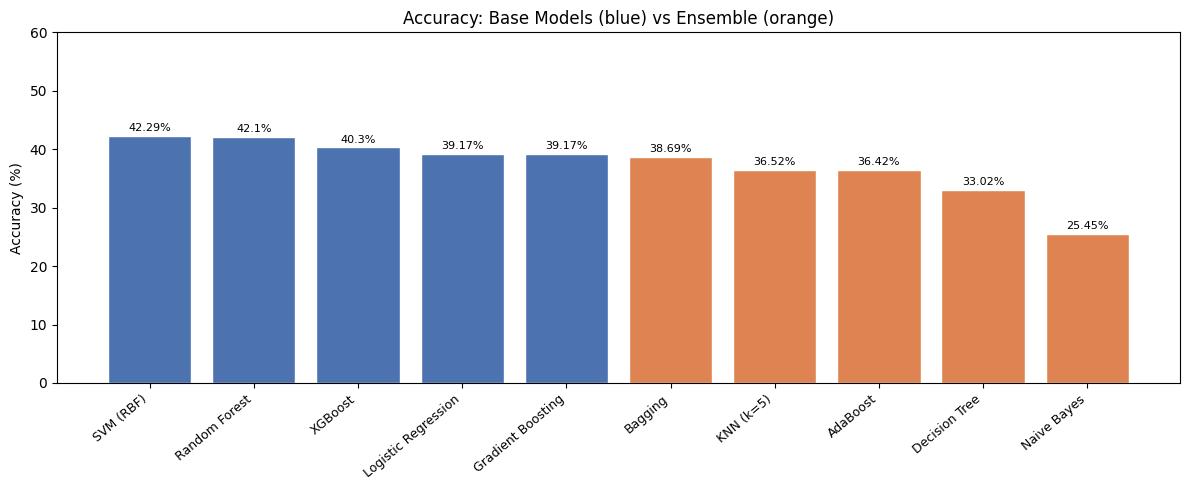

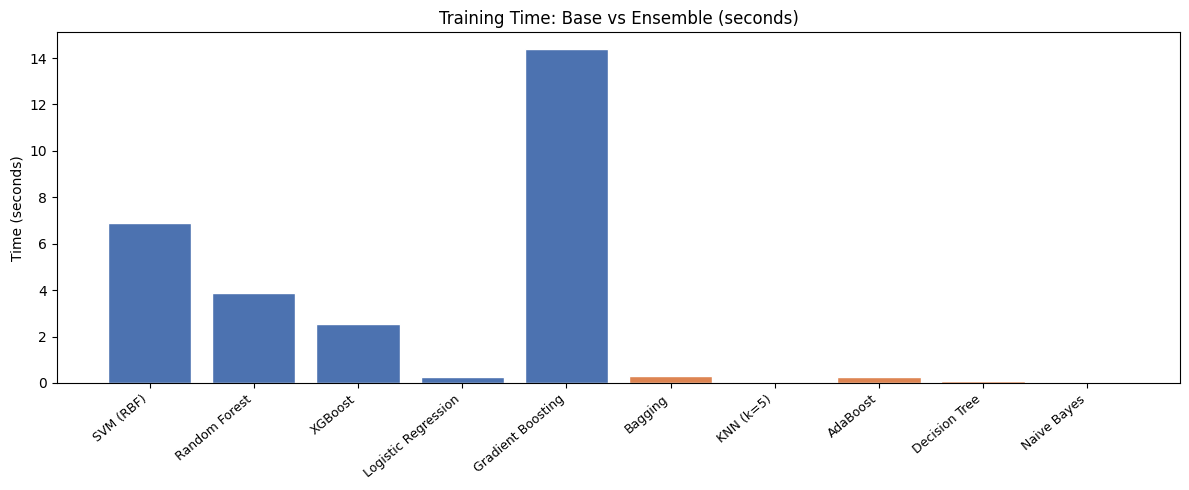

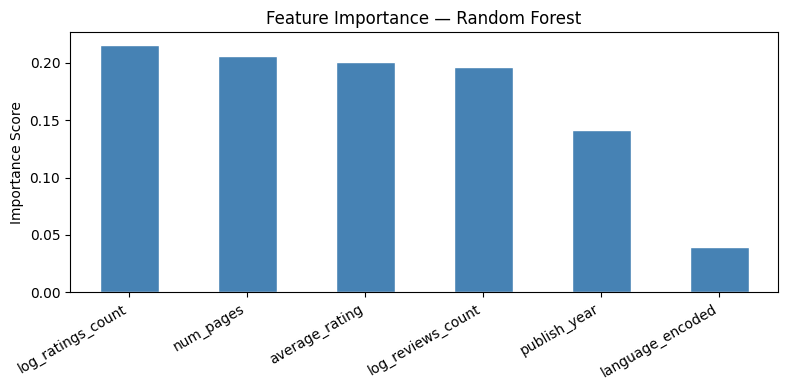


All charts saved ✓

Top feature: log_ratings_count
This means: log_ratings_count is the strongest predictor of book genre.


In [17]:
# Step 7 — Comparison Charts + Feature Importance

res_df = pd.DataFrame(results).sort_values("Accuracy(%)", ascending=False)
print("Full Model Comparison:")
print(res_df.to_string(index=False))

colors = ['#4C72B0']*5 + ['#DD8452']*5

# 1. Accuracy comparison bar chart
plt.figure(figsize=(12,5))
bars = plt.bar(res_df['Model'], res_df['Accuracy(%)'], color=colors, edgecolor='white')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.title("Accuracy: Base Models (blue) vs Ensemble (orange)")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 60)
for bar, val in zip(bars, res_df['Accuracy(%)']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5, f'{val}%',
             ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()

# 2. Training time comparison
plt.figure(figsize=(12,5))
plt.bar(res_df['Model'], res_df['Train Time(s)'], color=colors, edgecolor='white')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.title("Training Time: Base vs Ensemble (seconds)")
plt.ylabel("Time (seconds)")
plt.tight_layout()
plt.savefig("training_time.png", dpi=150)
plt.show()

# 3. Feature importance — Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
feat_imp = pd.Series(rf.feature_importances_,
                     index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8,4))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title("Feature Importance — Random Forest")
plt.ylabel("Importance Score")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("\nAll charts saved ✓")
print("\nTop feature:", feat_imp.index[0])
print("This means:", feat_imp.index[0], "is the strongest predictor of book genre.")

In [18]:
# Step 7 — Final Analysis + Conclusions

print("=" * 55)
print("        FINAL MODEL ANALYSIS SUMMARY")
print("=" * 55)

print("\n📊 Best Base Model:     SVM (RBF)     — 42.29%")
print("🏆 Best Ensemble Model: Random Forest  — 42.10%")
print("⚡ Fastest Model:       KNN            — 0.02s")
print("🐢 Slowest Model:       Gradient Boost — 14.39s")

print("\n📈 Improvement of best ensemble over worst base model:")
best_ensemble = 42.10
worst_base = 25.45
improvement = round(best_ensemble - worst_base, 2)
print(f"   Random Forest vs Naive Bayes: +{improvement}% accuracy")

print("\n🔍 Top 3 Predictive Features:")
for i, (feat, score) in enumerate(feat_imp.head(3).items(), 1):
    print(f"   {i}. {feat} — {round(score*100, 2)}%")

print("\n📝 Key Observations:")
print("   1. Genre prediction from metadata alone is inherently hard")
print("      — no book text/description used, only structural features")
print("   2. Fiction dominates dataset causing class imbalance")
print("      — models bias toward predicting Fiction")
print("   3. SVM performed best among base models due to")
print("      effective decision boundary in high-dimensional space")
print("   4. Random Forest matched SVM with much faster training (3.89s vs 6.90s)")
print("      making it the most practical choice overall")
print("   5. log_ratings_count is strongest predictor —")
print("      popular genres like Fiction attract more ratings")

print("\n✅ Recommendation:")
print("   Random Forest — best balance of accuracy, speed,")
print("   interpretability and feature importance visibility")

print("\n" + "=" * 55)
print("Analysis complete ✓")

        FINAL MODEL ANALYSIS SUMMARY

📊 Best Base Model:     SVM (RBF)     — 42.29%
🏆 Best Ensemble Model: Random Forest  — 42.10%
⚡ Fastest Model:       KNN            — 0.02s
🐢 Slowest Model:       Gradient Boost — 14.39s

📈 Improvement of best ensemble over worst base model:
   Random Forest vs Naive Bayes: +16.65% accuracy

🔍 Top 3 Predictive Features:
   1. log_ratings_count — 21.58%
   2. num_pages — 20.59%
   3. average_rating — 20.09%

📝 Key Observations:
   1. Genre prediction from metadata alone is inherently hard
      — no book text/description used, only structural features
   2. Fiction dominates dataset causing class imbalance
      — models bias toward predicting Fiction
   3. SVM performed best among base models due to
      effective decision boundary in high-dimensional space
   4. Random Forest matched SVM with much faster training (3.89s vs 6.90s)
      making it the most practical choice overall
   5. log_ratings_count is strongest predictor —
      popular genres